In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


In [140]:
df = pd.read_csv('train.csv',usecols=['Age' , 'Fare' , 'Survived']) 

In [141]:
x = df.drop(columns=['Survived'])
y =   df['Survived']

In [142]:
x_train,x_test ,y_train ,y_test  =train_test_split(x , y , test_size=0.2 , random_state=2)

In [143]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [144]:
x_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


## x_train.loc[condition, 'column_name'] = values

In [145]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test.loc[x_test['Age_imputed'].isnull() , 'Age_imputed'] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

In [146]:
x_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,59.0
493,71.0,49.5042,71.0
527,NaN,221.7792,25.0


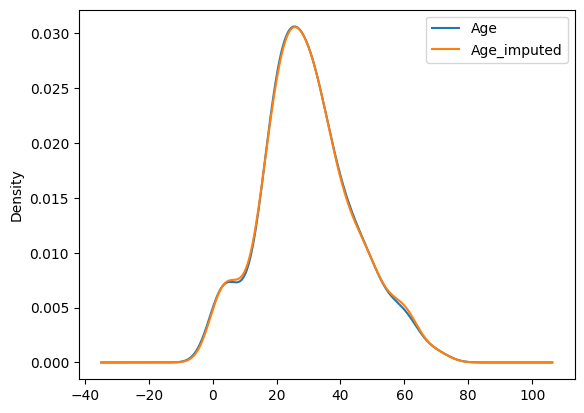

In [147]:
fig = plt.figure()
ax = fig.add_subplot(111)
x_train['Age'].plot(kind='kde')
x_train['Age_imputed'].plot(kind='kde')

lines , labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc = 'best')

plt.show()

In [148]:
print('Orignal Var' , x_train['Age'].var())
print('Orignal Var' , x_train['Age_imputed'].var())

Orignal Var 204.34951339046142
Orignal Var 207.18117327075336


In [149]:
x_train[['Fare' , 'Age' , 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,54.426577
Age,71.512440,204.349513,204.349513
Age_imputed,54.426577,204.349513,207.181173


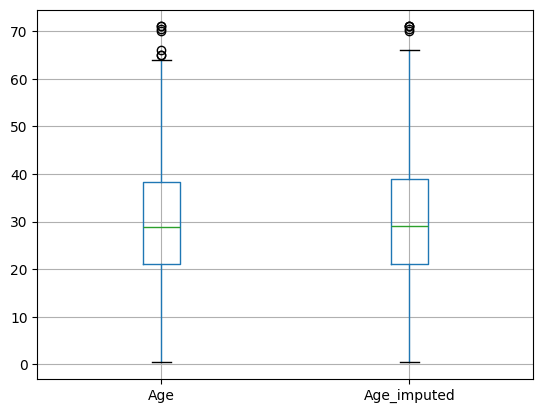

In [150]:
x_train[['Age' , 'Age_imputed']].boxplot()
plt.show()

# Genrating Same Age value if multiple user enter same Fare i created a sample production observation data and test it by giving same values

In [151]:
obs = pd.DataFrame({
    "Fare":[89]
})

sampled_value = x_train['Age'].dropna().sample(1, random_state=int(obs.iloc[0].iloc[0]))
sampled_value

144    18.0
Name: Age, dtype: float64

# ---------------------------------------------------------------------------------
# **Work on Categorical Data**
# ---------------------------------------------------------------------------------

In [152]:
data = pd.read_csv('houses.csv',usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [153]:
x = data
y = data['SalePrice']

In [154]:
x_train , x_test ,y_train ,y_test =train_test_split(x,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=2)

In [155]:
x_train['Imp_GarageQual'] = x_train['GarageQual']
x_test['Imp_GarageQual'] = x_test['GarageQual']

x_train['Imp_FireplaceQu']= x_train['FireplaceQu']
x_test['Imp_FireplaceQu'] = x_test['FireplaceQu']

In [156]:
x_train.head()

,FireplaceQu,GarageQual,SalePrice,Imp_GarageQual,Imp_FireplaceQu
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd


In [157]:
x_train.loc[x_train['Imp_GarageQual'].isnull() , "Imp_GarageQual"] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test.loc[x_test['Imp_GarageQual'].isnull() , "Imp_GarageQual"] = x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train.loc[x_train['Imp_FireplaceQu'].isnull() , "Imp_FireplaceQu"] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test.loc[x_test['Imp_FireplaceQu'].isnull() , "Imp_FireplaceQu"] = x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

In [160]:
temp = pd.concat([
    x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
    x_train['Imp_GarageQual'].value_counts() / len(x_train)
],axis = 1)

temp.columns=['Orignal' , 'Imputed']

In [162]:
temp2 = pd.concat([
    x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
    x_train['Imp_FireplaceQu'].value_counts() / len(x_train)
],axis = 1)

temp2.columns=['Orignal' , 'Imputed']

In [161]:
temp

,Orignal,Imputed
TA,0.951043,0.950342
Fa,0.037171,0.037671
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [163]:
temp2

,Orignal,Imputed
Gd,0.494272,0.494007
TA,0.412439,0.412671
Fa,0.040917,0.042808
Po,0.027823,0.027397
Ex,0.024550,0.023116


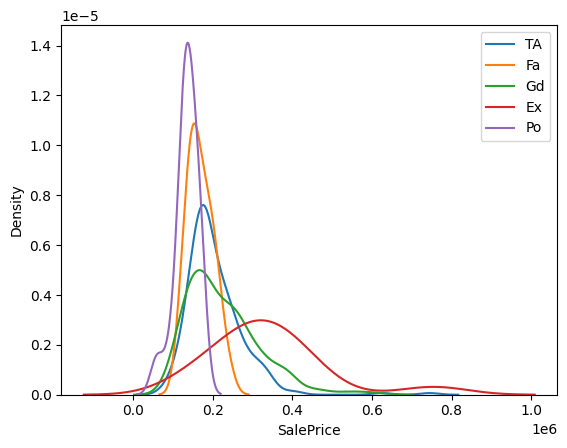

In [177]:
import seaborn as sns
for category in x_train['FireplaceQu'].dropna().unique() :
    sns.kdeplot(x_train[x_train['FireplaceQu'] == category ]['SalePrice'] , label=category)
    plt.legend()
plt.show()


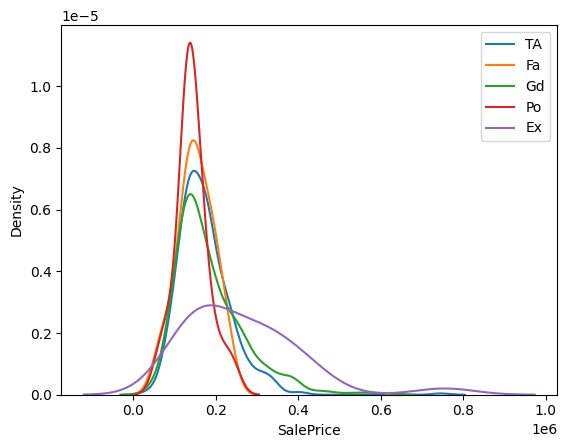

In [178]:
import seaborn as sns
for category in x_train['Imp_FireplaceQu'].dropna().unique() :
    sns.kdeplot(x_train[x_train['Imp_FireplaceQu'] == category ]['SalePrice'] , label=category)
    plt.legend()
plt.show()